# Teaching models to ask: active learning for pEC50 prediction

In drug discovery, the most valuable resource isn't compute, it's data. Synthesizing and assaying a single compound can cost thousands of dollars and take weeks. Yet, most machine learning models are trained as if labels are free, consuming massive random splits of [ChEMBL](https://www.ebi.ac.uk/chembl/) or [Enamine Real](https://enamine.net/compound-collections/real-compounds/real-database).

[**Active learning (AL)**](https://en.wikipedia.org/wiki/Active_learning_(machine_learning)) flips this paradigm. Instead of passively accepting a training set, the model iteratively selects the compounds it finds most confusing (to "explore") or promising (to "exploit"). In this post, we demonstrate how to build an active learning loop using [`openadmet-models`](https://github.com/OpenADMET/openadmet-models), powered by the [**CheMeleon**](https://github.com/JacksonBurns/chemeleon) foundation model. We'll simulate a campaign to find compounds active against the [Pregnane X Receptor (PXR)](https://en.wikipedia.org/wiki/Pregnane_X_receptor), starting with just 100 labeled molecules. By leveraging uncertainty quantification and smart acquisition strategies like expected improvement (EI) and upper confidence bound (UCB), we show that we can reach high predictive accuracy with a fraction of the data required by random screening.

## Why PXR?

PXR is a ligand-activated nuclear transcription factor that functions as the body's primary xenobiotic sensor, highly expressed in the liver and intestines. Structurally, PXR is defined by a uniquely large, flexible, and hydrophobic ligand-binding pocket, which makes it notoriously promiscuous and capable of accommodating a massive variety of chemical scaffolds.  When a molecule binds to PXR, it triggers the upregulation of crucial phase I and phase II drug-metabolizing enzymes (most significantly [CYP3A4](https://en.wikipedia.org/wiki/CYP3A4)) as well as phase III efflux transporters. This systemic enzyme induction aggressively accelerates the metabolic clearance of both the offending compound and any co-administered therapies, leading to severe [drug-drug interactions (DDIs)](https://en.wikipedia.org/wiki/Drug_interaction) and sub-therapeutic drug plasma levels. Because of this downstream cascade, PXR is treated as a high-priority absorbtion, metabolism, excretion, and toxicity ([ADMET](https://en.wikipedia.org/wiki/ADME)) antitarget. We model its binding affinity to computationally flag and optimize away this liability early in the drug design process, preventing compounds that trigger auto-induction or DDIs from advancing to costly clinical trials.

## The label bottleneck in drug discovery

A typical high-throughput screening (HTS) campaign might screen 100,000 compounds, but for lead optimization, we often work with much smaller datasets (hundreds to low thousands). When training predictive models on such small data, the choice of training points matters immensely. A model trained on 100 diverse, informative compounds will outperform one trained on 100 redundant analogues.

Active learning formalizes this intuition. We start with a small "seed" dataset, train an ensemble of models, and then use their consensus (mean) and disagreement (standard deviation) to query a large, unlabeled pool. This is often called [**query-by-committee (QBC)**](https://dl.acm.org/doi/10.1145/130385.130417). 

Here, we combine QBC with [**CheMeleon**](https://github.com/JacksonBurns/chemeleon), a graph neural network pretrained on millions of molecules. CheMeleon provides a robust chemical representation even when task-specific labels are scarce, making it an ideal backbone for low-data active learning.

Below we configure our imports and plotting configuration. To ensure you have your environment set up correctly, head over to `openadmet-models` on [GitHub](https://github.com/OpenADMET/openadmet-models) or corresponding [documentation](https://docs.openadmet.org/en/latest/) and follow the [installation instructions](https://docs.openadmet.org/en/latest/installation.html).

In [1]:
%matplotlib inline
%load_ext autoreload 
%autoreload 2

In [2]:
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from rdkit import Chem
from conf import STRATEGY_COLORS

import plots as alp
from helpers import (
    evaluate_on_test,
    featurize,
    run_active_learning,
    smiles_to_gtm,
    smiles_to_tmap,
)

warnings.filterwarnings("ignore")
import copy

import numpy as np
import torch
import uncertainty_toolbox as uct
from openadmet.models.split.scaffold import ScaffoldSplitter

We'll next define our global configuration parameters. These include
* `N_START`: the number of labeled training data points we will start with
* `M_QUERY`: the number of molecules queried per active learning cycle
* `K_ITER`: the number of active learning cycles to perform
* `N_MODELS`: the number of models that comprise our model ensemble
* `STRATEGIES`: list of active learning query strategies to compare

In [3]:
N_START = 100  # Initial labeled pool size
M_QUERY = 20  # Molecules queried per iteration
K_ITER = 15  # Active learning iterations
N_MODELS = 5  # Committee size
SEED = 42
STRATEGIES = ["EI", "UCB", "Random", "Exploitation", "Exploration", "Diversity"]
MAX_EPOCHS = 20

## A note on compute

Running a full active learning benchmark is computationally intensive because we retrain the model from scratch at every iteration to simulate a real campaign, repeated for each selection strategy to compare them. 

With $k=15$ iterations and 6 strategies, we are performing $15 \times 6 = 90$ full training runs. Each run trains a committee of 5 models. On a standard GPU (e.g. T4 or A10), this entire notebook might take several hours to complete compuations. If you want a quick preview, reduce `K_ITER` to `5` (with higher `M_QUERY`) and `N_MODELS` to `3`.

**Note:** The [**CheMeleon**](https://github.com/JacksonBurns/chemeleon) weights (~34MB) will be downloaded from [Zenodo](https://zenodo.org/records/15460715) automatically upon the first run.

## Load in the reference dataset

We won't be running an actual active learning campaign here for obvious reasons, but we can simulate one using a set of real, experimental data. We pretend we don't know the labels and, at each iteration, use what we learned from each synthetic AL cycle to drive next iteration selections. Rinse and repeat.


Dataset: 2167 compounds


,OPENADMET_CANONICAL_SMILES,OPENADMET_INCHIKEY,PXR_pEC50
0,CC1=NSC(C=O)=C1C(=O)N1CCC2(CCCC2)CC1,UNQJGGJIINFYEB-UHFFFAOYSA-N,4.30
1,CC1=CC(C=O)=C(O)C(C(=O)N2CCCC(C3=NNC(C)=C3)C2)=C1,SZXUROZHZWRMJP-UHFFFAOYSA-N,3.62
2,O=CC1=CC=C(C(=O)OCC(=O)NCCC2=CCCCC2)C=C1,KAGVIJNIEWAHGP-UHFFFAOYSA-N,3.42
3,O=CNC1=CC=CC(NC(=O)NCC=CC2=CC3=C(O)N(C4CCC(=O)...,FQLPILRQERTKEA-UHFFFAOYSA-N,1.62
4,O=CC1=CC=C(C(=O)OCC(=O)NCC2=CC=C(Cl)C=C2)C=C1,PNGFAYMEVQQJEK-UHFFFAOYSA-N,2.56


count    2167.000000
mean        4.806764
std         1.285089
min         1.610000
25%         3.925000
50%         5.060000
75%         5.694442
max         8.625000
Name: PXR_pEC50, dtype: float64


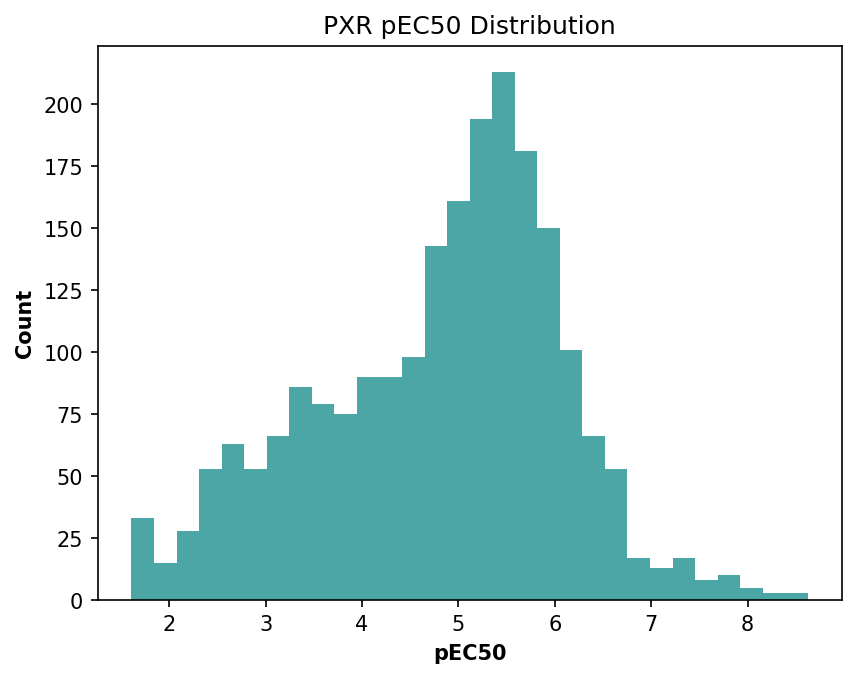

In [4]:
# Load data frame
df = pd.read_parquet(
    "~/repos/skunkworks/chemprop_mve/datasets/pxr/pxr_combined_canonical.parquet"
)

# Read full screen set
background_smiles = pd.read_csv("_data/octant_screening_compounds.csv")["Smiles"].values
background_smiles = [
    x for x in background_smiles if x not in df["OPENADMET_CANONICAL_SMILES"].values
]

# Print summary
print(f"Dataset: {len(df)} compounds")
display(df.head(5))
print(df["PXR_pEC50"].describe())

# Plot distribution
fig, ax = plt.subplots(1, dpi=150)
ax.hist(df["PXR_pEC50"], bins=30, color="teal", alpha=0.7)
ax.set_title("PXR pEC50 Distribution")
ax.set_xlabel("pEC50", fontweight="bold")
ax.set_ylabel("Count", fontweight="bold")
plt.show()

## Splitting the data: scaffold-based held-out test set
Random splitting is dangerously optimistic in drug discovery because it allows structurally similar molecules (analogues) to appear in both training and test sets. A model can "cheat" by memorizing the series rather than learning the [structure-activity relationship (SAR)](https://en.wikipedia.org/wiki/Structure%E2%80%93activity_relationship).

We use a **scaffold split** to separate the data based on [Bemis-Murcko scaffolds](https://practicalcheminformatics.blogspot.com/2021/10/exploratory-data-analysis-with.html). This forces the model to generalize to new chemical series, mimicking a prospective lead optimization scenario. This test set is fixed and held out for the entire active learning loop, ensuring a fair, apples-to-apples comparison across all iterations.

In [5]:
# Initialize Scaffold Splitter
splitter = ScaffoldSplitter(
    train_size=0.8, val_size=0.1, test_size=0.1, random_state=42
)

# Split the data
X_pool, X_cal, X_test, y_pool, y_cal, y_test, _ = splitter.split(
    df["OPENADMET_CANONICAL_SMILES"], df["PXR_pEC50"]
)

# Reconstruct DataFrames for convenience
df_pool = pd.DataFrame({"smiles": X_pool, "pEC50": y_pool}).reset_index(drop=True)
df_cal = pd.DataFrame({"smiles": X_cal, "pEC50": y_cal}).reset_index(drop=True)
df_test = pd.DataFrame({"smiles": X_test, "pEC50": y_test}).reset_index(drop=True)

# Guard to ensure pool is large enough
min_pool_needed = N_START + K_ITER * M_QUERY
assert len(df_pool) >= min_pool_needed, (
    f"Pool too small: {len(df_pool)} < {min_pool_needed}. "
    "Increase dataset size or reduce N_START/K_ITER/M_QUERY."
)

print(f"Pool size: \t\t{len(df_pool)}")
print(f"Calibration size: \t{len(df_cal)}")
print(f"Test size: \t\t{len(df_test)}")

Pool size: 		1637
Calibration size: 	216
Test size: 		314


## GTM chemical space embedding

The **Diversity** acquisition strategy selects compounds that are maximally dissimilar from the current labeled set in chemical space. To measure structural distance we use a **Generative Topographic Map (GTM)** — a probabilistic manifold projection that maps high-dimensional ECFP4 fingerprints onto an interpretable 2D grid. Each compound gets a single (x, y) coordinate, and pairwise Euclidean distances in that 2D space serve as a fast, interpretable proxy for molecular dissimilarity.

We fit the GTM once on the full unlabeled pool before the active learning loop starts so the embedding is fixed and consistent across all strategies.

In [ ]:
# Fit GTM on pool + background
gtm_model, gtm_coords, resps, llhs = smiles_to_gtm(
    list(df_pool["smiles"].values) + background_smiles,
    device="cpu",
)

# Split GTM outputs into pool and background
gtm_coords_pool = gtm_coords[: len(df_pool)]
gtm_coords_background = gtm_coords[len(df_pool) :]
resps_pool = resps[: len(df_pool)]
resps_background = resps[len(df_pool) :]
llhs_pool = llhs[: len(df_pool)]
llhs_background = llhs[len(df_pool) :]

## Query-by-committee: how ensemble disagreement guides exploration

Our committee consists of $N=5$ independent [**CheMeleon**](https://github.com/JacksonBurns/chemeleon) models. When we present an unlabeled molecule to the committee, we get 5 predictions. 

- The **mean** prediction ($\mu$) is our best guess for activity.
- The **standard deviation** ($\sigma$) represents epistemic uncertainty.

Different acquisition strategies leverage these metrics:
- **Exploitation**: Greedy selection of the highest $\mu$. Finds good compounds fast but can get stuck in local optima.
- **Upper Confidence Bound (UCB)**: $\mu + \beta\sigma$. Optimistically explores regions that *might* be high activity.
- **Expected Improvement (EI)**: Balances $\mu$ and $\sigma$ to calculate the probability of exceeding the current best label $f^*$ (equation below).
- **Exploration**: Pure uncertainty sampling — selects the $m$ compounds with the highest $\sigma$, ignoring predicted activity entirely. Useful as a model-agnostic baseline that maximises coverage of the epistemic uncertainty landscape.
- **Diversity**: Ignores model predictions altogether and instead selects the $m$ compounds that are farthest from the current labeled set in 2D GTM chemical space (max-min Euclidean distance). This enforces structural dissimilarity between batches and prevents the committee from over-sampling a single region of chemical space.

$EI(\mathbf{x}) = (\mu(\mathbf{x}) - f^* - \xi)\,\Phi(Z) + \sigma(\mathbf{x})\,\phi(Z)$

where $Z = \frac{\mu(\mathbf{x}) - f^* - \xi}{\sigma(\mathbf{x})}$.


To achieve ensemble diversity, we vary the initialization of each ensemble member ([deep ensembling](https://dl.acm.org/doi/10.5555/3295222.3295387)) and [bootstrap](https://en.wikipedia.org/wiki/Bootstrap_aggregating) the labeled set for each member (sampling with replacement). It is precisely this diversity, captured as disagreement between members at prediction time, that gives our committee meaningful epistemic uncertainty to feed into the acquisition function.

We deliberately *aren't* using a held out set for calibration, despite stressing its importance of in another [blog post](https://openadmet.ghost.io/concerning-uncertainty/). **Exploration**, **EI**, and **UCB** use σ to rank unlabeled molecules, i.e. the molecule with the highest acquisition score gets queried next. A miscalibrated σ (e.g., overconfident by a constant factor of 2×) will compress all uncertainty estimates equally, but the relative ordering among candidates is preserved. The committee will still correctly identify that compound A is more uncertain than compound B, even if both σvalues are off in absolute terms. Scaling factor or [isotonic regression](https://en.wikipedia.org/wiki/Isotonic_regression) fix the scale so that \"90% interval\" actually covers 90% of outcomes — but it does not reorder the candidates. We thus wait to calibrate after all active learning cycles have been completed, to yield our final model with meaningful uncertainties.

Practically speaking, you also need a held-out calibration set to perform calibration. At every iteration, you'd have to carve off some labeled molecules as a calibration subset rather than using them to train the committee. Early in the loop — say iteration 2 with 140 labeled molecules total — a calibration set of even 30 compounds makes calibration unreliable and weakens the committee.

## The active learning loop
 
We chunked out each discrete step into (helper functions)[ADD_LINK]: `featurize` prepares the data, `train_committee` fits a bootstrapped ensemble on the current labeled set, `query_batch` uses the committee's μ and σ (or GTM distances, for *Diversity*) to select the next $m$ molecules, and `evaluate_on_test` scores the updated model on the fixed test set, all bookended by `build_committee_member`, which ensures each ensemble member is constructed consistently. These four steps repeat $k$ times, with each new batch of oracle-labeled molecules feeding back into the next training call. The six strategies — **EI**, **UCB**, **Random**, **Exploitation**, **Exploration**, and **Diversity** — are all handled by `query_batch` via a single `strategy` argument. 

Now we assemble the loop. In each iteration $k$:
1. Train the committee on the current `labeled_pool`.
2. Evaluate on the static `test_set` to track performance.
3. Use the committee to predict on the `unlabeled_pool`.
4. Score the unlabeled molecules with the acquisition function.
5. "Acquire" the top $m$ molecules (reveal their labels).
6. Add them to the `labeled_pool` and repeat.

We track not just accuracy (MAE), but also the *quality* of the molecules we found (their pEC50 values). A good AL strategy should find the potent hits early.

## Running the experiments

We now run the loop for all defined strategies with a fixed seed. This is the main computational block and will take some time.

In [8]:
# Made output directory if it doesn't exist
if not Path("results").exists():
    Path("results").mkdir()

# Load results from pickle file if it exists
if Path("results/all_runs.pkl").exists():
    with open("results/all_runs.pkl", "rb") as handle:
        all_runs = pickle.load(handle)

# Otherwise initialize empty dictionary
else:
    all_runs = {}

all_runs.keys()

dict_keys(['EI', 'UCB', 'Random', 'Exploitation', 'Exploration', 'Diversity'])

In [9]:
for strategy in STRATEGIES:
    # Check if this strategy has already been run and skip if so
    if strategy not in all_runs.keys():
        run_result = run_active_learning(strategy, SEED, df_pool, df_test, verbose=True)
        all_runs[strategy] = run_result

    # Checkpoint results in case of long runtimes or crashes
    with open("results/all_runs.pkl", "wb") as handle:
        pickle.dump(all_runs, handle, protocol=pickle.HIGHEST_PROTOCOL)

## Unpacking results into tidy `DataFrames`

The `all_runs` dictionary stores the raw output of every active learning run, keyed first by strategy and then by iteration. Each iteration snapshot contains the test-set metrics, the number of labeled molecules at that point, and the pEC50 values of every compound that has been added to the labeled pool so far.

We unpack this nested structure into two tidy long-format DataFrames:

* **`learning_curve_long`** — one row per (strategy, iteration), carrying the test-set metrics (MAE, R², Kendall's τ, Spearman ρ) and the corresponding labeled-pool size `n_labeled`. This is the primary input for all learning-curve plots.
* **`pool_history_long`** — one row per (strategy, iteration, compound), recording the pEC50 of every molecule in the labeled pool at each iteration. This lets us track how the distribution of acquired labels shifts over the course of the campaign — a window into *what* each strategy is choosing to label, not just *how well* the model performs.

In [10]:
records = []
pool_history_records = []

for strategy in STRATEGIES:
    run_data = all_runs[strategy]["history"]
    for step in run_data:
        records.append(
            {
                "strategy": strategy,
                "iteration": step["iteration"],
                "n_labeled": step["n_labeled"],
                "mae": step["mae"],
                "r2": step["r2"],
                "ktau": step["ktau"],
                "spearmanr": step["spearmanr"],
            }
        )
        for pval in step["pool_y_values"]:
            pool_history_records.append(
                {
                    "strategy": strategy,
                    "iteration": step["iteration"],
                    "pEC50": float(pval),
                }
            )

learning_curve_long = pd.DataFrame(records)
pool_history_long = pd.DataFrame(pool_history_records)
print(
    f"Curve rows: {len(learning_curve_long)}, Pool history rows: {len(pool_history_long)}"
)

Curve rows: 96, Pool history rows: 24000


Because this experiment uses a **single random seed**, there is no cross-seed variance to collapse. `learning_curve_summary` is therefore constructed by renaming the raw metric columns to the `_mean` suffix expected by the plotting functions, then duplicating those values as `_lower` and `_upper` confidence bounds — effectively zero-width bands. This keeps all downstream plotting calls compatible with the multi-seed band-plot API without requiring any changes to the plot helpers.

In [11]:
# Single-run: keep mean/lower/upper schema for downstream plotting compatibility
learning_curve_summary = (
    learning_curve_long[["strategy", "n_labeled", "mae", "ktau", "r2"]]
    .rename(columns={"mae": "mae_mean", "ktau": "ktau_mean", "r2": "r2_mean"})
    .copy()
)

# No seed variance — lower and upper equal the mean
for metric in ["mae", "ktau", "r2"]:
    learning_curve_summary[f"{metric}_lower"] = learning_curve_summary[f"{metric}_mean"]
    learning_curve_summary[f"{metric}_upper"] = learning_curve_summary[f"{metric}_mean"]

## Results

We visualize the performance of our active learning loop. The schematic below reminds us of the process we just executed. Following that, we look at the learning curves for MAE and Kendall's $\tau$.

In [10]:
fig = alp.plot_learning_curve_with_bands(
    learning_curve_summary,
    metric_col="mae",
    ylabel="MAE (pEC50 units)",
    strategy_order=STRATEGIES,
    color_map=STRATEGY_COLORS,
)
fig.show()

fig = alp.plot_learning_curve_with_bands(
    learning_curve_summary,
    metric_col="ktau",
    ylabel="Kendall's τ",
    strategy_order=STRATEGIES,
    color_map=STRATEGY_COLORS,
)
fig.show()

In [12]:
fig = alp.plot_hit_discovery_curve(
    pool_history_long,
    learning_curve_long,
    hit_threshold=7.0,
    strategy_order=STRATEGIES,
    color_map=STRATEGY_COLORS,
)
fig.show()

As expected, **EI** and **UCB** outperform **Random** sampling significantly in the early iterations (100–250 labeled molecules). The gap narrows as the pool grows, but the "area under the learning curve" advantage for active learning is substantial.

**Exploitation** initially improves fast but often plateaus or degrades slightly because it over-samples a single chemical series (the "greedy" trap), failing to explore the diversity of the scaffold split.

**Exploration** behaves as a pure uncertainty oracle: it queries regions where the model is most confused, which drives rapid improvement early on but eventually saturates once the model has adequate coverage. Without any signal from predicted activity it can waste queries on low-activity regions.

**Diversity** enforces structural dissimilarity at every step, spreading labels uniformly across chemical space. This prevents the committee from over-committing to a single scaffold and tends to produce well-calibrated models, but it can be slow to find potent hits because it ignores predicted activity entirely.

Crucially, even at $N=100$, the MAE is reasonable (~0.7-0.8), thanks to CheMeleon's pretraining. A randomly initialized model would likely be much worse.

## Navigating chemical space with GTM

Learning curves tell us *how fast* a strategy converges, but they say nothing about *where* in chemical space each strategy chooses to look. A strategy that exploits a single potent scaffold may show an early MAE drop while leaving most of the chemical diversity untouched — a dangerous blind spot in a real campaign.

We already fit the **GTM** embedding on the full compound pool before the active learning loop (see the setup section above) — this is the same `gtm_coords` array the **Diversity** strategy uses at each iteration to select structurally dissimilar compounds. Here we reuse it for visualisation, replaying the **EI** selection history iteration by iteration:

* **Gray** — the full compound pool (all available unlabeled candidates)
* **Blue** — compounds acquired in any *prior* iteration (accumulated history)
* **Red** — compounds selected in the *current* iteration

Use the slider to step through iterations manually, or press **▶ Play** to watch the campaign unfold on repeat.

In [23]:
_method = "Exploitation"
fig = alp.plot_gtm_selection_animation(
    gtm_coords=gtm_coords_pool.values,
    background_gtm_coords=gtm_coords_background.values,
    selection_history=all_runs[_method]["history"],
    title=f"{_method} Compound Selection in GTM Chemical Space",
)
fig.update_layout(
    autosize=False,
    width=800,
    height=800,
)
fig.show()
fig.write_html(f"results/gtm_selection_animation_{_method.lower()}.html")

In [10]:
tmap_layout = smiles_to_tmap(list(df_pool["smiles"].values) + background_smiles)

In [12]:
alp.plot_tmap_faerun(
    tmap_layout,
    n_background=len(background_smiles),
    smiles_list=df_pool["smiles"].values,
    selection_history=all_runs["EI"]["history"],
    point_scale=3,
    background_point_scale=1,
    title="Active Learning Selection (TMAP)",
    output_name="tmap_selection",
    output_path="./results/",
)


/Users/smcolby/repos/active-learning-blogpost/results/tmap_selection.html

## Are our uncertainties trustworthy?

A model with good MAE can still be overconfident. In active learning, this is dangerous: if the model is confident but wrong about an unlabeled region, it may never query it (for **EI** / **UCB**). We tackeld the topic of model uncertainty in another OpenADMET blogpost, [Concerning Uncertainty](https://openadmet.ghost.io/concerning-uncertainty/).

We evaluate calibration using the **miscalibration area**. A perfectly calibrated model has e.g. 90% of data points falling within its 90% confidence interval. We can improve this post-hoc using **scaling factor** calibration on a small holdout set.

In [ ]:
# Get the EI committee from final iteration
committee_final = all_runs["EI"]["committee"]

# Pre-calibration metrics
print("Evaluating *before* calibration...")
res_pre = evaluate_on_test(committee_final, df_test["smiles"], df_test["pEC50"])

# Reshape and featurize calibration
y_cal = df_cal["pEC50"].values.reshape(-1, 1)
X_cal_loader, _ = featurize(df_cal["smiles"].values)

# Calibrate
print("Calibrating...")
committee_calibrated = copy.deepcopy(committee_final)
committee_calibrated.calibrate_uncertainty(X_cal_loader, y_cal, method="scaling-factor")

# Post-calibration metrics
print("Evaluating *after* calibration...")
res_post = evaluate_on_test(committee_calibrated, df_test["smiles"], df_test["pEC50"])

# Metrics before
exp_pre, obs_pre = uct.metrics_calibration.get_proportion_lists_vectorized(
    res_pre["y_test_pred"], res_pre["y_test_std"], df_test["pEC50"].values
)

# Metrics after
exp_post, obs_post = uct.metrics_calibration.get_proportion_lists_vectorized(
    res_post["y_test_pred"], res_post["y_test_std"], df_test["pEC50"].values
)

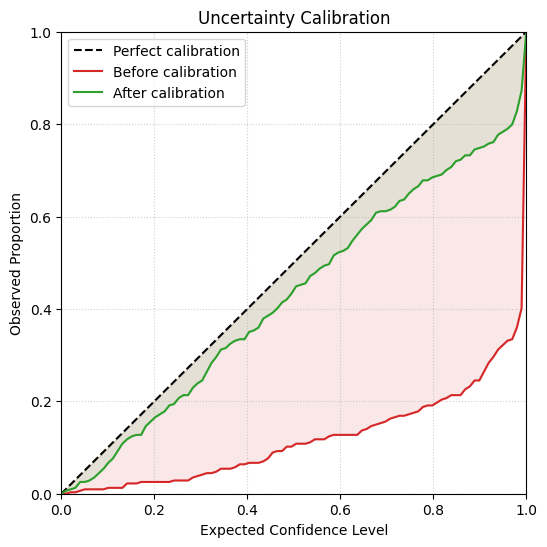

Miscalibration Area Before: 0.3806
Miscalibration Area After:  0.0736


In [25]:
# Plot calibration curve
fig = alp.plot_calibration_curve_before_after(exp_pre, obs_pre, exp_post, obs_post)
fig.show()

print(f"Miscalibration Area Before: {res_pre['miscal_area']:.4f}")
print(f"Miscalibration Area After:  {res_post['miscal_area']:.4f}")

The plot shows how isotonic regression pulls the calibration curve closer to the diagonal. For early-stage AL, this ensures that the acquisition function (which relies on $\sigma$) is making decisions based on realistic uncertainty estimates, preventing the model from ignoring "unknown unknowns."

## Takeaways
1.  **Efficiency**: **EI** and **UCB** consistently reach performance milestones with fewer labels than random sampling. In this simulation, EI often reaches the target MAE with 20-30% fewer compounds.
2.  **Exploitation is risky**: Pure greedy strategies converge fast but often stagnate. They find local maxima but fail to learn the global SAR.
3.  **Exploration covers unknowns**: Sampling purely by uncertainty ($\sigma$) maps the epistemic landscape quickly but wastes queries on inactive regions once the model matures. It serves as a useful diagnostic — if **Exploration** outperforms **EI**, the committee is under-exploring and would benefit from a higher $\beta$ or $\xi$.
4.  **Diversity ensures coverage**: GTM-based max-min selection prevents scaffold collapse and produces the most structurally diverse labeled set. It is the safest strategy when potency information is completely absent, but it sacrifices hit-finding speed.
5.  **Foundation Models matter**: CheMeleon provides a strong prior. Even with $N=100$, the models are performant. Active learning is most effective when the base model is already capable of reasoning about chemical structure.
6.  **Calibration is (almost) free**: Post-hoc uncertainty calibration significantly improves reliability without retraining, which is crucial for safety-critical decision making, but does require a held-out calibration set.
7.  **Recommendation**: For early-stage screening, use **EI**. It naturally balances finding hits (for the project team) and learning the SAR (for the model). Once you have >300 labels and the model is stable, you might switch to pure exploitation or standard screening.

## Limitations and next steps
-   **Time Split**: A scaffold split is a good proxy, but a true temporal split (training on data < 2020, testing on > 2020) is the gold standard.
-   **Batch Awareness**: We selected the top $m$ compounds independently. Advanced "batch active learning" ensures diversity *within* the query batch to avoid selecting identical analogues. The **Diversity** strategy already addresses this implicitly by maximising structural dissimilarity from the labeled set.

Check out the [`openadmet-models`](https://github.com/OpenADMET/openadmet-models) repository for the full code and more advanced featurizers.
